### House Price Prediction  

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

display(train.head())

Train Shape: (1460, 13)
Test Shape: (1459, 13)


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   MSSubClass    1460 non-null   int64  
 2   MSZoning      1460 non-null   object 
 3   LotArea       1460 non-null   int64  
 4   LotConfig     1460 non-null   object 
 5   BldgType      1460 non-null   object 
 6   OverallCond   1460 non-null   int64  
 7   YearBuilt     1460 non-null   int64  
 8   YearRemodAdd  1460 non-null   int64  
 9   Exterior1st   1460 non-null   object 
 10  BsmtFinSF2    1460 non-null   float64
 11  TotalBsmtSF   1460 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 148.4+ KB


In [4]:
train.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,729.500000,56.897260,10516.828082,5.575342,1971.267808,1984.865753,46.549315,1057.429452,180921.195890
std,421.610009,42.300571,9981.264932,1.112799,30.202904,20.645407,161.319273,438.705324,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,364.750000,20.000000,7553.500000,5.000000,1954.000000,1967.000000,0.000000,795.750000,129975.000000
50%,729.500000,50.000000,9478.500000,5.000000,1973.000000,1994.000000,0.000000,991.500000,163000.000000
75%,1094.250000,70.000000,11601.500000,6.000000,2000.000000,2004.000000,0.000000,1298.250000,214000.000000
max,1459.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1474.000000,6110.000000,755000.000000


In [5]:
#For categorical variables
train.describe(include="object")

,MSZoning,LotConfig,BldgType,Exterior1st
count,1460,1460,1460,1460
unique,5,5,5,15
top,RL,Inside,1Fam,VinylSd
freq,1151,1052,1220,515


In [6]:
train.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [7]:
print("Duplicate rows:", train.duplicated().sum())

#checking duplicate IDs

print("Duplicate IDs:", train["Id"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0


In [8]:
target = "SalePrice"

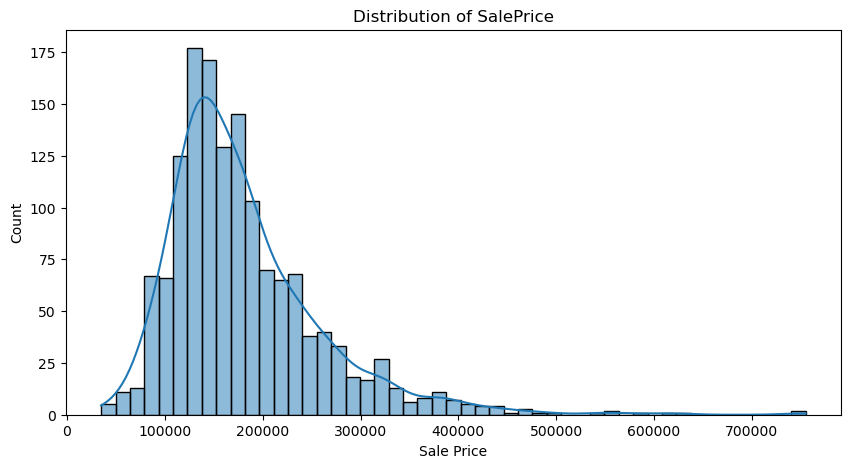

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(train["SalePrice"], kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.show()

In [10]:
train["SalePriceLog"] = np.log1p(train["SalePrice"])

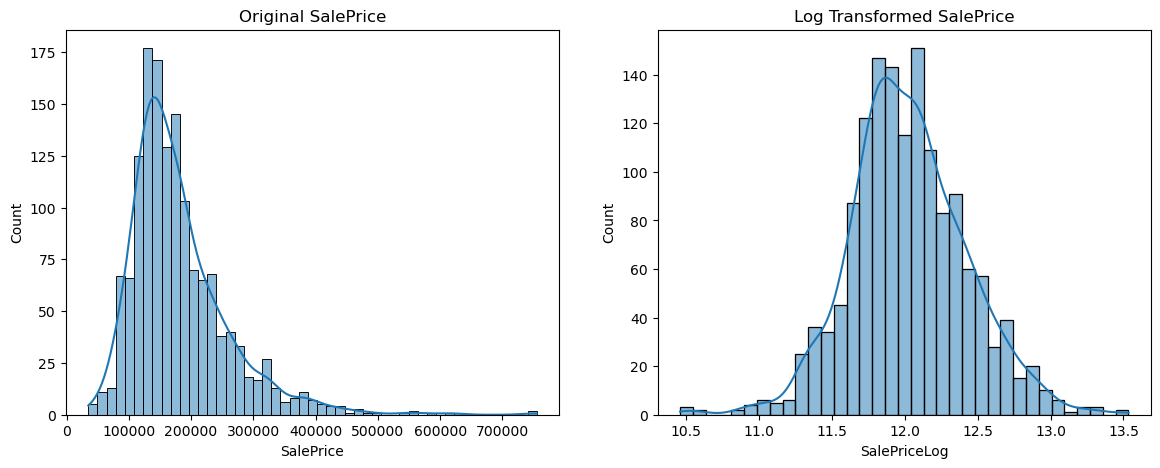

In [11]:
#Compare distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("Original SalePrice")

sns.histplot(train["SalePriceLog"], kde=True, ax=axes[1])
axes[1].set_title("Log Transformed SalePrice")

plt.show()

In [12]:
#Getting numerical columns
numeric_features = train.select_dtypes(
    include=["int64", "float64"]
).columns

print(numeric_features)

Index(['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice',
       'SalePriceLog'],
      dtype='object')


In [13]:
numeric_features = [
    col for col in numeric_features
    if col not in ["SalePrice", "SalePriceLog"]
]

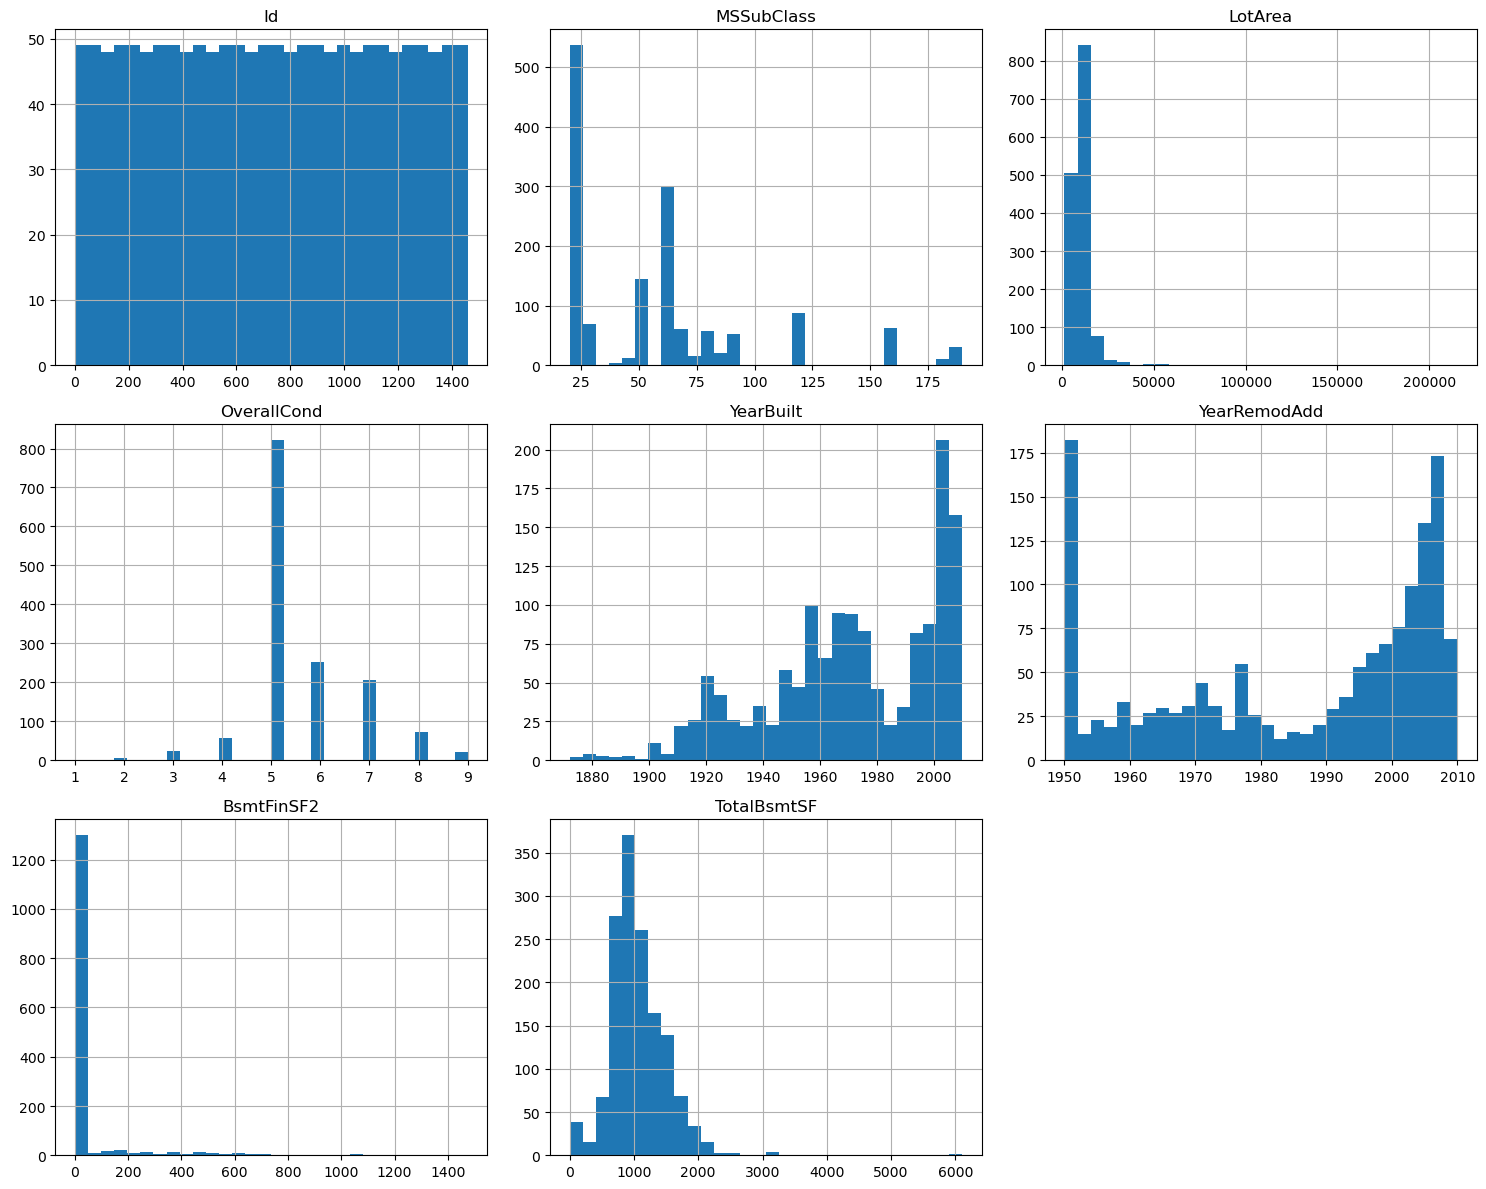

In [14]:
#Plot distributions
train[numeric_features].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

In [15]:
# Categorical features
categorical_features = train.select_dtypes(
    include=["object"]
).columns

print(categorical_features)

Index(['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], dtype='object')


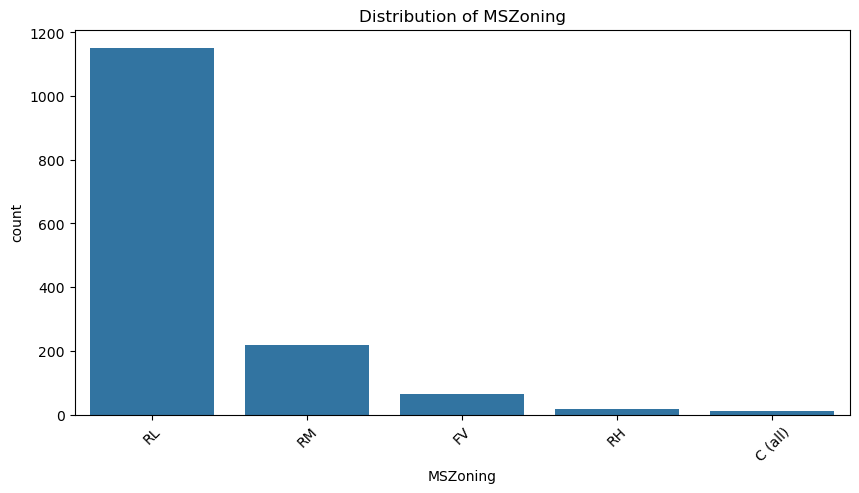

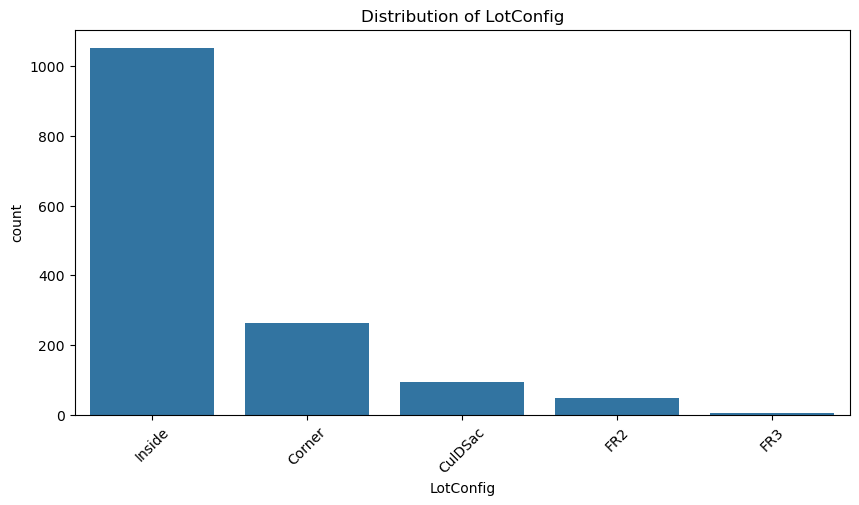

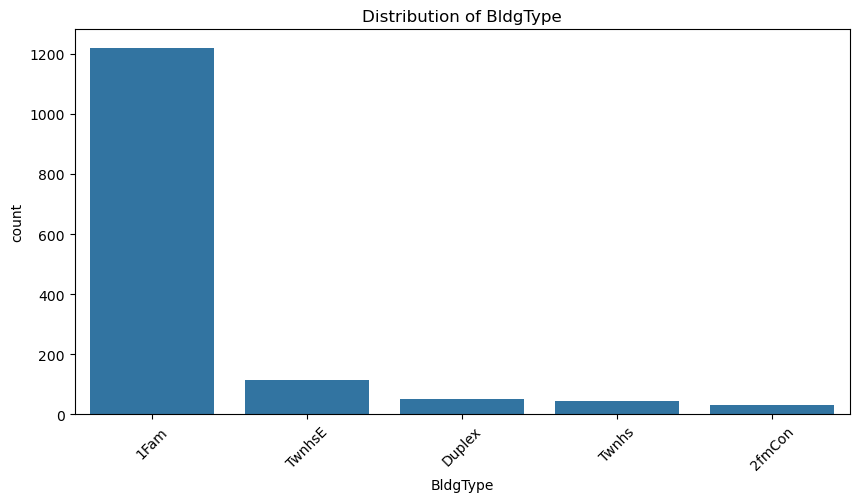

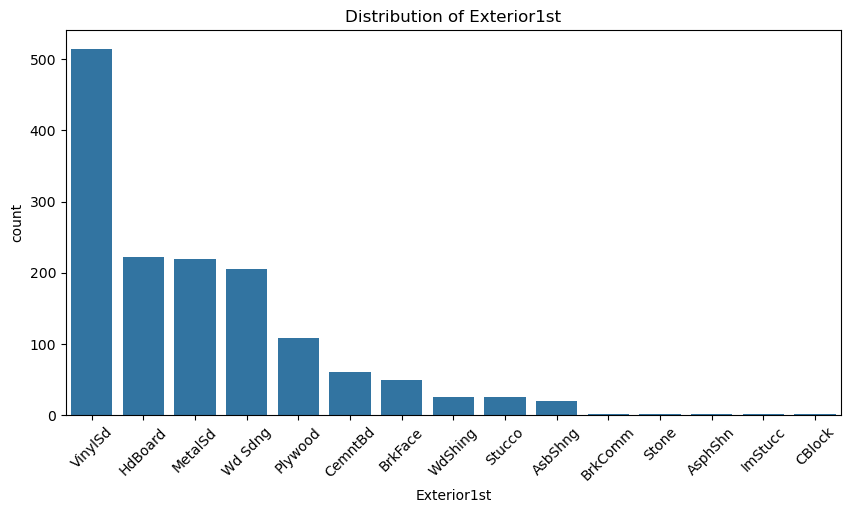

In [16]:
for col in categorical_features:

    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=train,
        x=col,
        order=train[col].value_counts().index
    )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

    plt.show()

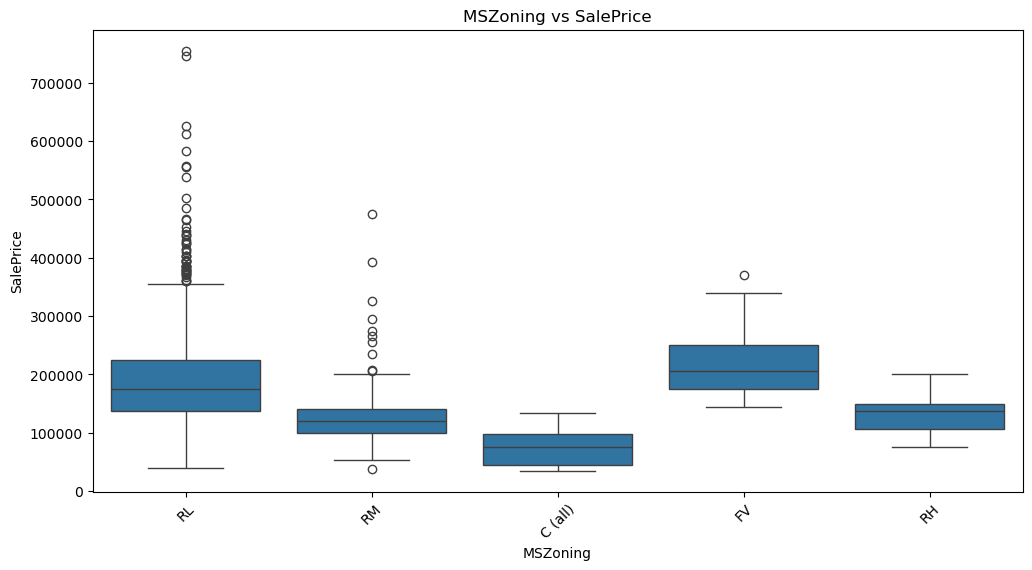

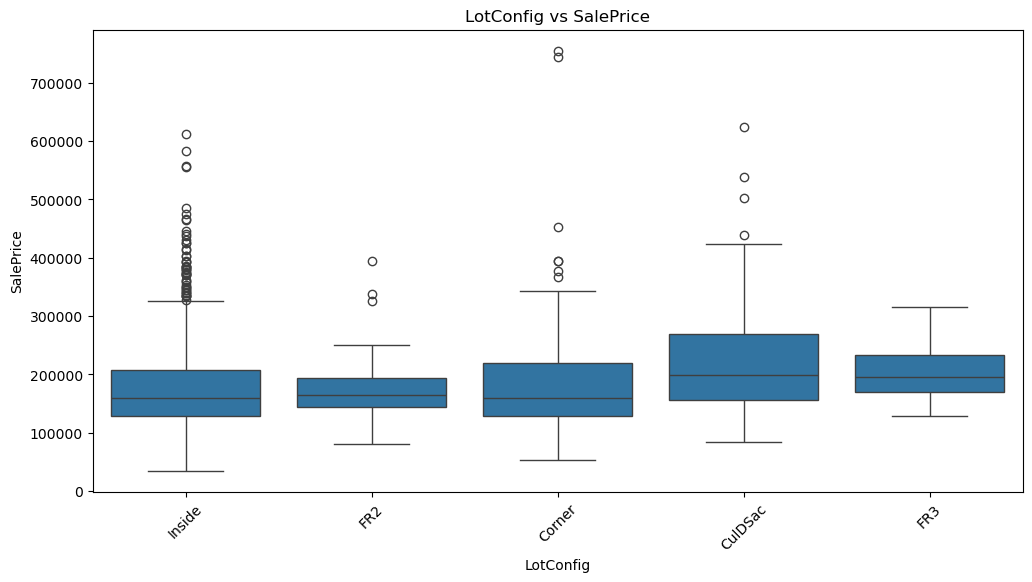

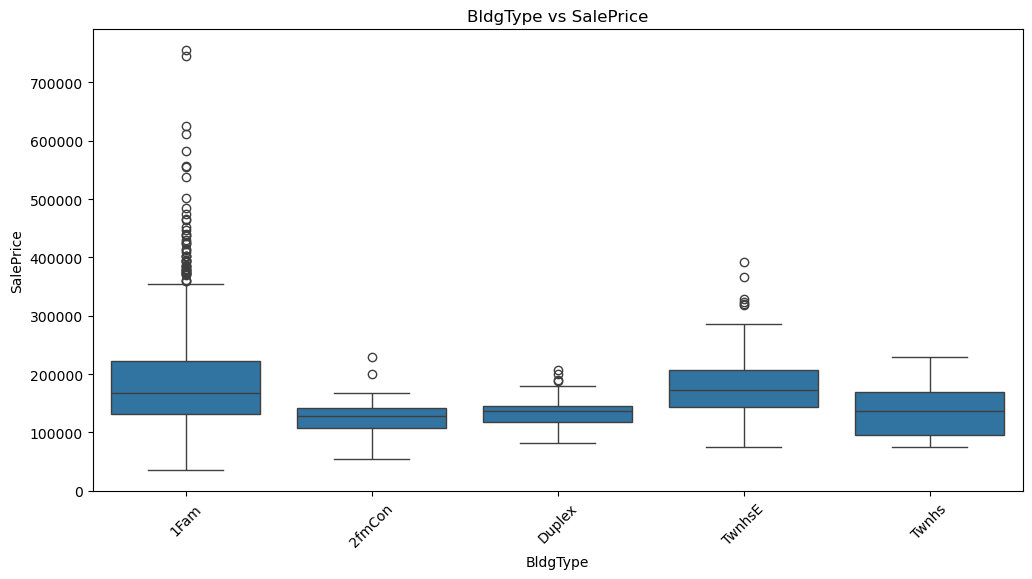

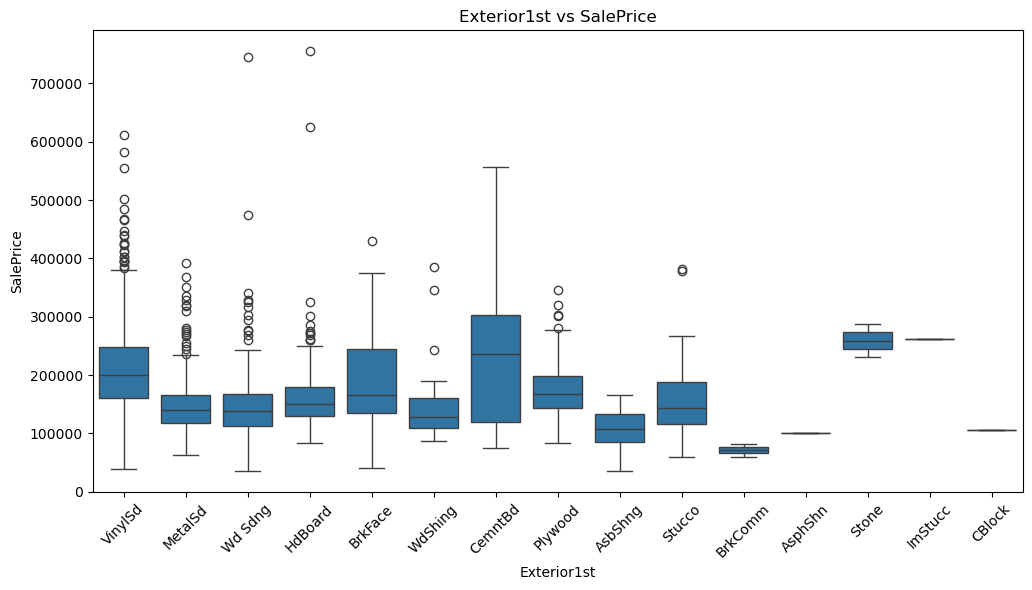

In [17]:
# Categorical features vs house price
for col in categorical_features:

    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=train,
        x=col,
        y="SalePrice"
    )

    plt.title(f"{col} vs SalePrice")
    plt.xticks(rotation=45)

    plt.show()

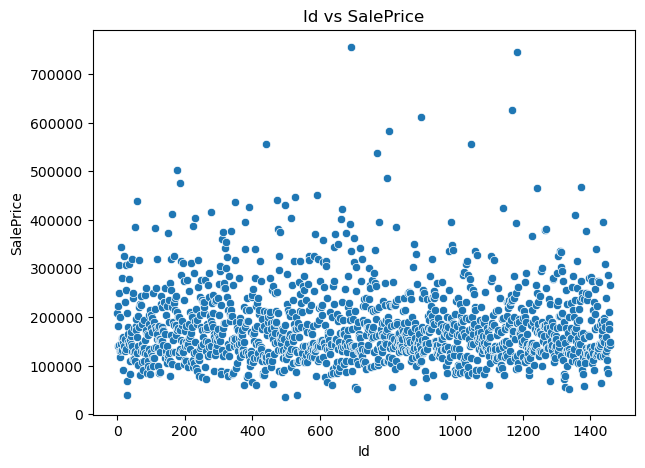

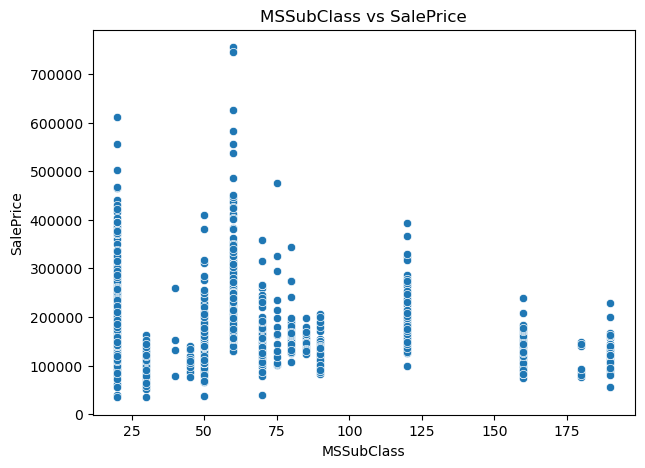

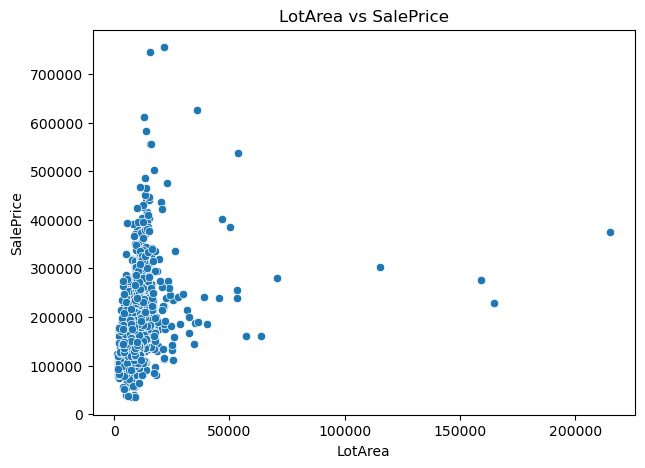

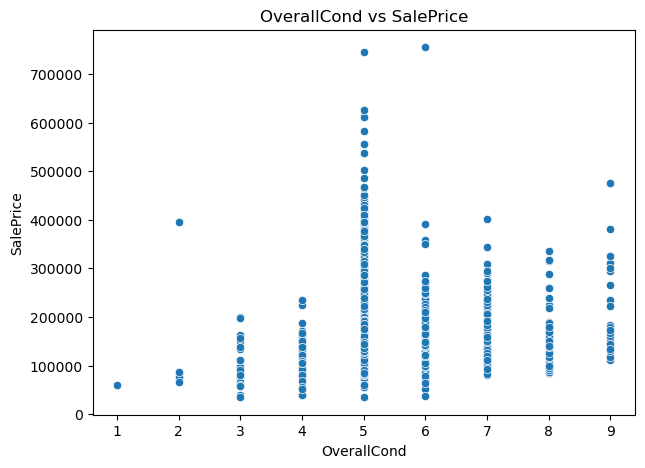

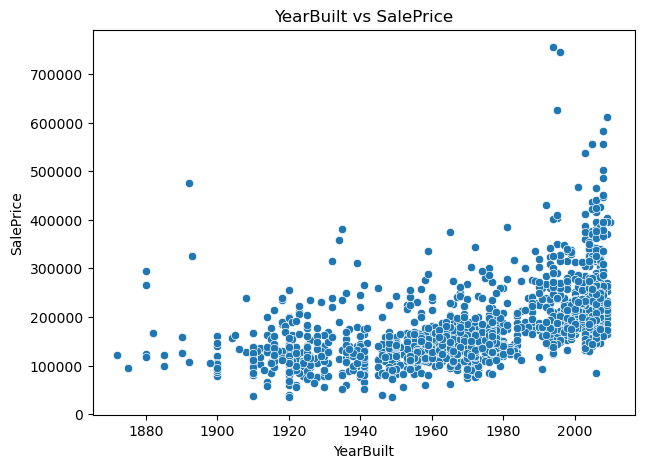

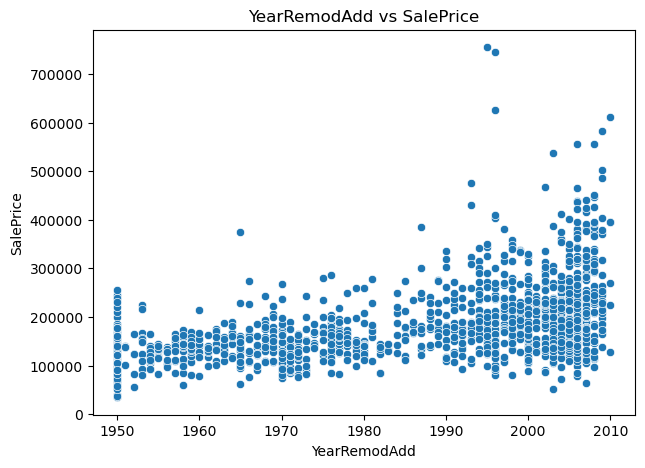

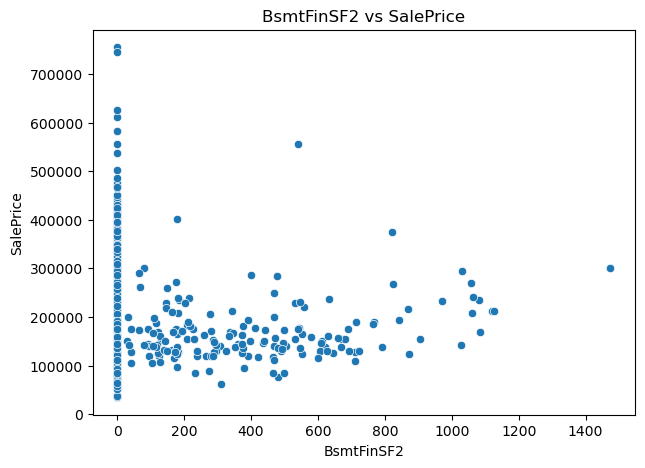

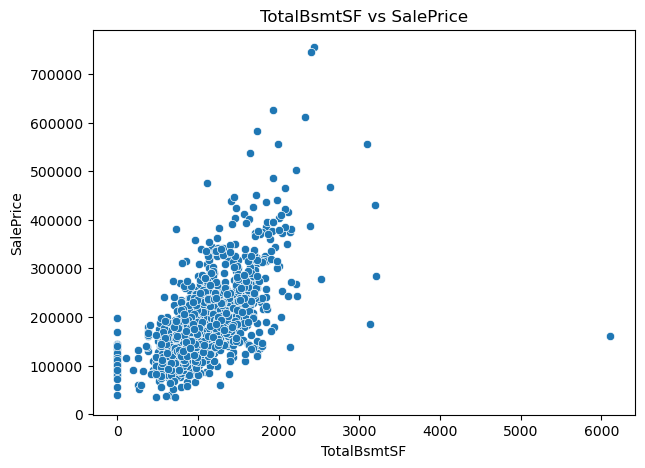

In [18]:
# Numerical features vs SalePrice

for col in numeric_features:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=train,
        x=col,
        y="SalePrice"
    )

    plt.title(f"{col} vs SalePrice")

    plt.show()

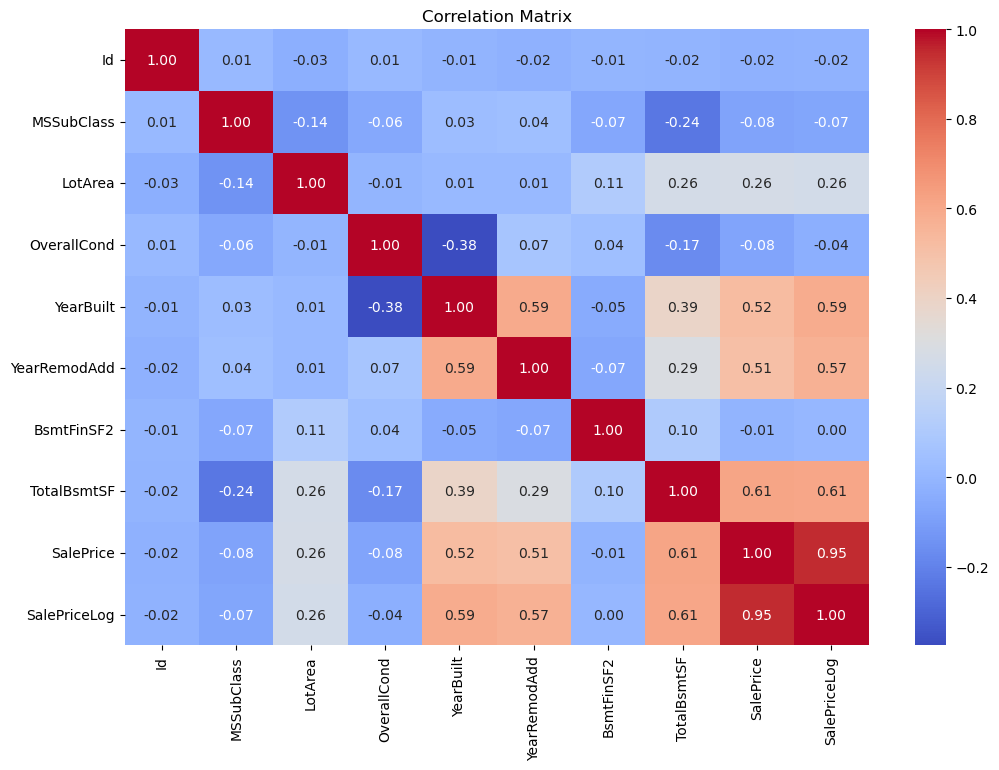

In [19]:
# Correlation analysis
plt.figure(figsize=(12, 8))

corr = train.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [20]:
# Correlation with target
target_corr = (
    train.select_dtypes(include=["int64", "float64"])
    .corr()["SalePrice"]
    .sort_values(ascending=False)
)

print(target_corr)

SalePrice       1.000000
SalePriceLog    0.948374
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
Id             -0.021917
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64


## Feature Engineering

In [21]:
def feature_engineering(df):

    df = df.copy()

    current_year = 2026

    df["HouseAge"] = current_year - df["YearBuilt"]

    df["RemodAge"] = current_year - df["YearRemodAdd"]

    df["YearsSinceRemod"] = (
        df["YearRemodAdd"] - df["YearBuilt"]
    )

    return df

In [22]:
def feature_engineering(df):

    df = df.copy()

    df["RemodelAge"] = (
        df["YearRemodAdd"] - df["YearBuilt"]
    )
    # Total basement-related area

    df["TotalFinishedBasement"] = (
        df["TotalBsmtSF"].fillna(0) +
        df["BsmtFinSF2"].fillna(0)
    )

    # Lot area transformation

    df["LogLotArea"] = np.log1p(df["LotArea"])
    # Basement transformation

    df["LogTotalBsmtSF"] = np.log1p(
        df["TotalBsmtSF"].fillna(0)
    )
    # Interaction features


    df["OverallCond_YearBuilt"] = (
        df["OverallCond"] *
        df["YearBuilt"]
    )

    df["LotArea_Cond"] = (
        df["LotArea"] *
        df["OverallCond"]
    )

    # Missing categorical values

    categorical_cols = df.select_dtypes(
        include="object"
    ).columns

    for col in categorical_cols:
        df[col] = df[col].fillna("Missing")

    # Missing numerical values
 
    numerical_cols = df.select_dtypes(
        include=["int64", "float64"]
    ).columns

    for col in numerical_cols:
        df[col] = df[col].fillna(
            df[col].median()
        )

    return df

In [23]:
train_fe = feature_engineering(train.drop(columns=["SalePriceLog"]))

test_fe = feature_engineering(test)

In [24]:
print(train_fe.shape)
print(test_fe.shape)

(1460, 19)
(1459, 19)


In [25]:
X = train_fe.drop(columns=["SalePrice", "Id"])
y = np.log1p(train_fe["SalePrice"])

X_test = test_fe.drop(columns=["SalePrice", "Id"])

In [26]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numeric_features)

Categorical: ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
Numerical: ['MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'RemodelAge', 'TotalFinishedBasement', 'LogLotArea', 'LogTotalBsmtSF', 'OverallCond_YearBuilt', 'LotArea_Cond']


In [27]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
print(X.head())
print(y.head())


   MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  YearBuilt  \
0          60       RL     8450    Inside     1Fam            5       2003   
1          20       RL     9600       FR2     1Fam            8       1976   
2          60       RL    11250    Inside     1Fam            5       2001   
3          70       RL     9550    Corner     1Fam            5       1915   
4          60       RL    14260       FR2     1Fam            5       2000   

   YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  RemodelAge  \
0          2003     VinylSd         0.0        856.0           0   
1          1976     MetalSd         0.0       1262.0           0   
2          2002     VinylSd         0.0        920.0           1   
3          1970     Wd Sdng         0.0        756.0          55   
4          2000     VinylSd         0.0       1145.0           0   

   TotalFinishedBasement  LogLotArea  LogTotalBsmtSF  OverallCond_YearBuilt  \
0                  856.0    9.042040       

## Model 1 — CatBoost

In [29]:
cat_indices = [
    X.columns.get_loc(col)
    for col in categorical_features
]

In [30]:
cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_state=42,
    verbose=200
)

cat_model.fit(
    X_train,
    y_train,
    cat_features= cat_indices,
    eval_set=(X_valid,y_valid),
    early_stopping_rounds=100
)

0:	learn: 0.3837473	test: 0.4261611	best: 0.4261611 (0)	total: 125ms	remaining: 4m 10s
200:	learn: 0.1453950	test: 0.1833551	best: 0.1832121 (196)	total: 10s	remaining: 1m 29s
400:	learn: 0.1230714	test: 0.1771431	best: 0.1770832 (397)	total: 19.2s	remaining: 1m 16s
600:	learn: 0.1090044	test: 0.1765962	best: 0.1763755 (581)	total: 27.5s	remaining: 1m 3s
800:	learn: 0.0974697	test: 0.1764257	best: 0.1762049 (713)	total: 35.8s	remaining: 53.6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.176204944
bestIteration = 713

Shrink model to first 714 iterations.


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=2000, learning_rate=0.03, loss_function='RMSE', random_state=42, verbose=200)

In [31]:
# Evaluate CatBoost

pred_log= cat_model.predict(X_valid)

rmse_log = np.sqrt(
    mean_squared_error(y_valid , pred_log)
)

mae_log = mean_absolute_error(
    y_valid,
    pred_log
)

r2 = r2_score(
    y_valid,
    pred_log
)

print("RMSE:", rmse_log)
print("MAE:", mae_log)
print("R2:", r2)

RMSE: 0.17620493158286432
MAE: 0.12222651189604987
R2: 0.8336208486494944


In [32]:
#Convert prediction back to the actual price 

pred_price = np.expm1(pred_log)
actual_price = np.expm1(y_valid)

rmse_price = np.sqrt(
    mean_squared_error(
        actual_price,
        pred_price
    )
)

mae_price = mean_absolute_error(
    actual_price,
    pred_price
)

print("Price RMSE:", rmse_price)
print("Price MAE:", mae_price)


Price RMSE: 36020.896302540896
Price MAE: 21996.952597771982
